In [1]:
from math import sqrt
import cmath
import numpy as np
import ase
from ase import Atoms
import scipy
from scipy.constants import hbar,pi
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

In [2]:
def rot(theta):
    return np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

In [24]:
a0 = 2.46 
t = 2.7#eV
vf = 3/2 * a0 * t #eV.Ang, fermi velocity
w = 0.1 # eV

theta=1.8
am=a0/(theta/180*pi)

icell=4*np.pi/(3*am)*np.array(([[np.sqrt(3)/2,1/2],[np.sqrt(3)/2,-1/2]]))

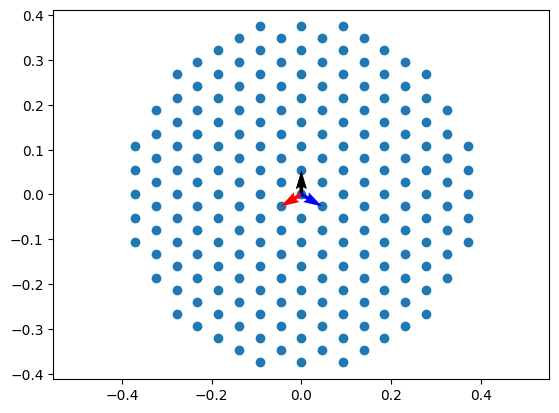

In [25]:
g1 = np.array([0, 4*pi/(3*am)])
g2=rot(+2*np.pi/3).dot(g1)
g3=rot(-2*np.pi/3).dot(g1)

Ecut=4
N=30
G=[]

for i in range(-N,N+1):
    for j in range(-N,N+1):
        G.append(i*icell[0]+j*icell[1])
        
G=np.array(G)
Ekin=vf*np.linalg.norm(G,axis=-1)
G=G[Ekin<Ecut]
# Ekin=vf*np.linalg.norm(G,axis=-1)
# G=G[np.argsort(Ekin)]

plt.figure()
plt.scatter(G[:,0],G[:,1])
plt.quiver(0, 0, g1[0],g1[1],angles='xy', scale_units='xy', scale=1,label = "g1,g2,g3")
plt.quiver(0, 0, g2[0],g2[1],angles='xy', scale_units='xy', scale=1,color='red')
plt.quiver(0, 0, g3[0],g3[1],angles='xy', scale_units='xy', scale=1,color='blue')
plt.axis('equal')
plt.show()


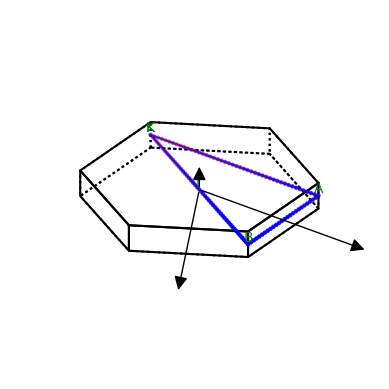

In [26]:
from ase import Atoms
from ase.dft.kpoints import bandpath
import numpy as np
import matplotlib.pyplot as plt

#NEW PATH------------path of the paper 
a = 2.46  # lattice constant in angstroms
c = 15.0  # vacuum spacing in the z direction for a monolayer
cell = [
    [ a, 0, 0],
    [-a / 2, np.sqrt(3) / 2 * a, 0],
    [0, 0, c]
]
cll=np.array(cell)
# Create an Atoms object for graphene with this cell
graphene = Atoms(cell=cell, pbc=True)  

points = {
    'K': [-1/3, -1/3, 0],
    'G': [0, 0, 0],
    'A': [-1/3, 2/3, 0],
    'B': [1/3, 1/3, 0],
}

# path in the cell
path_sequence = "KGBAK"
#create band path
band_path = bandpath(path=path_sequence, cell=graphene.cell,special_points=points, npoints = 120)

band_path.plot()
plt.show()
# Get kpoints along the path
kpts_lin, sympoint_name, labels = band_path.get_linear_kpoint_axis()
qpts=band_path.kpts[:,:2]
kpts=qpts.dot(icell)

In [27]:
epsilon = 1e-6
g1_indx = []
g2_indx = []
g3_indx = []

dG=G[:,None]-G[None,:]

g1p_indx = np.where(np.linalg.norm(dG + g1[None, None, :], axis=-1) < epsilon)
g2p_indx = np.where(np.linalg.norm(dG + g2[None, None, :], axis=-1) < epsilon)
g3p_indx = np.where(np.linalg.norm(dG + g3[None, None, :], axis=-1) < epsilon)

g1p_indx=np.array(g1p_indx)
g2p_indx=np.array(g2p_indx)
g3p_indx=np.array(g3p_indx)

gp_indx=[g1p_indx,g2p_indx,g3p_indx]

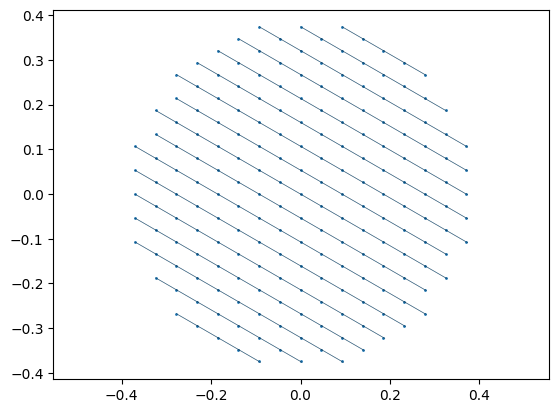

In [28]:
plt.figure()
plt.scatter(G[:,0],G[:,1],s=1)
for i,j in zip(*g3p_indx):
    # plt.arrow([G[i,0],G[j,0]],[G[i,1],G[j,1]])
    plt.arrow(G[i,0],G[i,1],dx=G[j,0]-G[i,0],dy=G[j,1]-G[i,1],lw=0.1)
plt.axis('equal')
plt.show()

In [29]:
s0 = np.array([[1, 0], [0, 1]])
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

T=np.zeros((3,2,2),dtype=complex)

T[0]=w*(s0+sx)
T[1]=w*(s0+np.cos(2*np.pi/3)*sx+np.sin(2*np.pi/3)*sy)
T[2]=w*(s0+np.cos(2*np.pi/3)*sx-np.sin(2*np.pi/3)*sy)
N=len(G)

# Generate hamiltonian
def hamiltonian(k,kz=0):
    
 
    kG=(k+G)

    H = np.zeros((N,N,2,2), dtype=complex)  # Pre-allocate H
    #size 2N^2 x 2N^2 since each element 2x2 matrices

    # --------------Add Hkin matrix----------------
    for i in range(N):
        H[i,i] += vf * kG[i,0]*sx
        H[i,i] += vf * kG[i,1]*sy

# #    #--------------Cacluating the potential Delta--------------
    for j,indx in enumerate(gp_indx):
        for a,b in zip(*indx):
            H[a,b]=(T[j]*np.exp(2j*pi*kz)+T[j].T.conj()*np.exp(-2j*pi*kz))
            H[b,a]=H[a,b].T.conj()

    H=H.transpose((0,2,1,3)).reshape((2*N,2*N))
    return H

    

<Figure size 640x480 with 0 Axes>

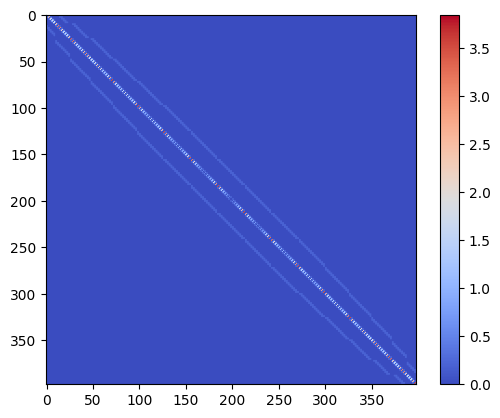

In [30]:
plt.figure()

h=hamiltonian(k=[0,0],kz=0)
plt.figure()
plt.imshow(np.abs(h),cmap='coolwarm')
plt.colorbar()
# plt.axis('equal')
plt.show()

In [31]:
e=[]
for kpt in tqdm(kpts):
    e.append(np.linalg.eigvalsh(hamiltonian(kpt,kz=0)))
e=np.array(e)

e0=np.linalg.eigvalsh(hamiltonian([0,0],kz=0))
n=len(e0)
fermi=(e0[n//2-1]+e0[n//2])/2

x, x_ticks, x_labels = band_path.get_linear_kpoint_axis()


100%|██████████| 120/120 [00:07<00:00, 16.76it/s]


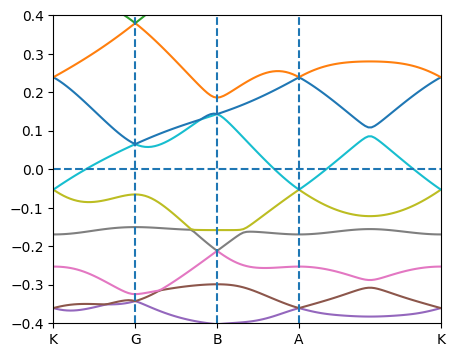

In [32]:
plt.figure(figsize=(5, 4))
plt.plot(kpts_lin,e-fermi)
plt.ylim([-0.4,0.4])
plt.axhline(0,linestyle='--')
plt.xticks(x_ticks,x_labels)
for x_ in x_ticks[1:-1]:
    plt.axvline(x_,linestyle='--')
plt.xlim([x.min(),x.max()])
plt.show()